# Dataset Exploration: Comprehensive Overview for TF-IDF + UGC Recommendation

This notebook evaluates all available datasets for content-based recommendation using TF-IDF + UGC:

- **archive_2**: Food.com recipes and interactions
- **archive_3**: Recipe reviews dataset
- **archive_4**: Yelp academic dataset (business, reviews, tips, users)
- **archive_6**: Food coding dataset
- **onlinefoods.csv**: Online food orders dataset
- **OpenFoodFacts**: Global food products database (TSV)

**Goal**: Evaluate datasets for TF-IDF + UGC content-based recommendation

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Set data directory
DATA_DIR = Path('../data')

# Helper function for JSON lines
def load_json_lines(filepath, nrows=None):
    """Load JSON lines file efficiently"""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if nrows and i >= nrows:
                break
            data.append(json.loads(line))
    return pd.DataFrame(data)

print("✅ Environment setup complete!")

✅ Environment setup complete!


## 1. Archive_2: Food.com Dataset

In [2]:
print("=" * 80)
print("ARCHIVE_2: Food.com Dataset")
print("=" * 80)

archive_2_dir = DATA_DIR / 'archive_2'
recipes_a2 = pd.read_csv(archive_2_dir / 'PP_recipes.csv')
interactions_train = pd.read_csv(archive_2_dir / 'interactions_train.csv')

print(f"\n📊 Recipes: {recipes_a2.shape} | Interactions: {interactions_train.shape}")
print(f"Columns: {list(recipes_a2.columns[:10])}...")
display(recipes_a2.head(2))

# Text columns for TF-IDF
text_cols_a2 = [col for col in recipes_a2.columns if any(kw in col.lower() 
                for kw in ['name', 'ingredient', 'step', 'tag', 'description'])]
print(f"\n🔤 Text columns: {text_cols_a2}")

ARCHIVE_2: Food.com Dataset

📊 Recipes: (178265, 8) | Interactions: (698901, 6)
Columns: ['id', 'i', 'name_tokens', 'ingredient_tokens', 'steps_tokens', 'techniques', 'calorie_level', 'ingredient_ids']...


,id,i,name_tokens,ingredient_tokens,steps_tokens,techniques,calorie_level,ingredient_ids
0,424415,23,"[40480, 37229, 2911, 1019, 249, 6878, 6878, 28...","[[2911, 1019, 249, 6878], [1353], [6953], [153...","[40480, 40482, 21662, 481, 6878, 500, 246, 161...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[389, 7655, 6270, 1527, 3406]"
1,146223,96900,"[40480, 18376, 7056, 246, 1531, 2032, 40481]","[[17918], [25916], [2507, 6444], [8467, 1179],...","[40480, 40482, 729, 2525, 10906, 485, 43, 8393...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[2683, 4969, 800, 5298, 840, 2499, 6632, 7022,..."



🔤 Text columns: ['name_tokens', 'ingredient_tokens', 'steps_tokens', 'ingredient_ids']


## 2. Archive_3: Recipe Reviews Dataset

In [3]:
print("=" * 80)
print("ARCHIVE_3: Recipe Reviews Dataset")
print("=" * 80)

archive_3_dir = DATA_DIR / 'archive_3'
recipes_a3 = pd.read_parquet(archive_3_dir / 'recipes.parquet') if (archive_3_dir / 'recipes.parquet').exists() else pd.read_csv(archive_3_dir / 'recipes.csv')
reviews_a3 = pd.read_parquet(archive_3_dir / 'reviews.parquet') if (archive_3_dir / 'reviews.parquet').exists() else pd.read_csv(archive_3_dir / 'reviews.csv')

print(f"\n📊 Recipes: {recipes_a3.shape} | Reviews: {reviews_a3.shape}")
display(recipes_a3.head(2))
display(reviews_a3.head(2))

# UGC analysis
review_text_cols = [col for col in reviews_a3.columns if 'text' in col.lower() or 'review' in col.lower()]
print(f"\n💬 UGC columns: {review_text_cols}")

ARCHIVE_3: Recipe Reviews Dataset

📊 Recipes: (522517, 28) | Reviews: (1401982, 8)


,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions
0,38.0,Low-Fat Berry Blue Frozen Dessert,1533,Dancer,PT24H,PT45M,PT24H45M,1999-08-09 21:46:00+00:00,Make and share this Low-Fat Berry Blue Frozen ...,[https://img.sndimg.com/food/image/upload/w_55...,...,1.3,8.0,29.8,37.1,3.6,30.2,3.2,4.0,NaN,"[Toss 2 cups berries with sugar., Let stand fo..."
1,39.0,Biryani,1567,elly9812,PT25M,PT4H,PT4H25M,1999-08-29 13:12:00+00:00,Make and share this Biryani recipe from Food.com.,[https://img.sndimg.com/food/image/upload/w_55...,...,16.6,372.8,368.4,84.4,9.0,20.4,63.4,6.0,NaN,[Soak saffron in warm milk for 5 minutes and p...


,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified
0,2,992,2008,gayg msft,5,better than any you can get at a restaurant!,2000-01-25 21:44:00+00:00,2000-01-25 21:44:00+00:00
1,7,4384,1634,Bill Hilbrich,4,"I cut back on the mayo, and made up the differ...",2001-10-17 16:49:59+00:00,2001-10-17 16:49:59+00:00



💬 UGC columns: ['ReviewId', 'Review']


## 3. Archive_4: Yelp Academic Dataset ⭐

In [4]:
print("=" * 80)
print("ARCHIVE_4: Yelp Academic Dataset (JSON)")
print("=" * 80)
print("⚠️  Loading samples only (10k-50k rows) due to large file size\n")

archive_4_dir = DATA_DIR / 'archive_4'

# Load business data
business_a4 = load_json_lines(archive_4_dir / 'yelp_academic_dataset_business.json', nrows=10000)
print(f"\n📍 Business: {business_a4.shape}")
print(f"Columns: {list(business_a4.columns)}")
display(business_a4.head(2))

# Filter food-related
if 'categories' in business_a4.columns:
    food_businesses = business_a4[business_a4['categories'].notna() & 
                                   business_a4['categories'].str.contains('Restaurant|Food|Cafe', case=False, na=False)]
    print(f"\n🍽️  Food-related: {len(food_businesses)} / {len(business_a4)} ({len(food_businesses)/len(business_a4)*100:.1f}%)")

ARCHIVE_4: Yelp Academic Dataset (JSON)
⚠️  Loading samples only (10k-50k rows) due to large file size


📍 Business: (10000, 14)
Columns: ['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours']


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."



🍽️  Food-related: 4280 / 10000 (42.8%)



💬 Reviews (UGC): (50000, 9)


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18



📝 Review text stats: Mean=547, Median=393 chars
Sample review:
If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. 

The food is good, but it takes a very long time to come out. The w...


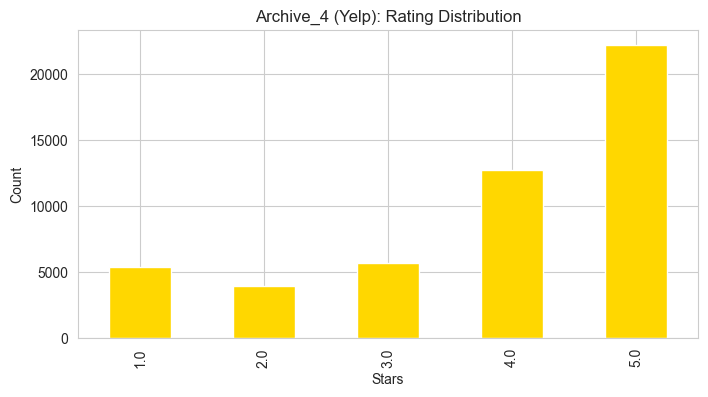

In [ ]:
# 餐厅评论表 (用户生成内容)
reviews_a4 = load_json_lines(archive_4_dir / 'yelp_academic_dataset_review.json', nrows=50000)
print(f"\n💬 Reviews (UGC): {reviews_a4.shape}")
display(reviews_a4.head(2))

if 'text' in reviews_a4.columns:
    review_lens = reviews_a4['text'].str.len()
    print(f"\n📝 Review text stats: Mean={review_lens.mean():.0f}, Median={review_lens.median():.0f} chars")
    print(f"Sample review:\n{reviews_a4['text'].iloc[0][:300]}...")

# Rating distribution
if 'stars' in reviews_a4.columns:
    plt.figure(figsize=(8, 4))
    reviews_a4['stars'].value_counts().sort_index().plot(kind='bar', color='gold')
    plt.title('Archive_4 (Yelp): Rating Distribution')
    plt.xlabel('Stars')
    plt.ylabel('Count')
    plt.show()

In [6]:
# Load tips (short UGC)
tips_a4 = load_json_lines(archive_4_dir / 'yelp_academic_dataset_tip.json', nrows=20000)
print(f"\n💡 Tips (Short UGC): {tips_a4.shape}")
display(tips_a4.head(2))

# Load users
users_a4 = load_json_lines(archive_4_dir / 'yelp_academic_dataset_user.json', nrows=10000)
print(f"\n👥 Users: {users_a4.shape}")
if 'review_count' in users_a4.columns:
    print(f"Avg reviews per user: {users_a4['review_count'].mean():.1f}")


💡 Tips (Short UGC): (20000, 5)


,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0



👥 Users: (10000, 22)
Avg reviews per user: 278.6


## 4. Archive_6: Food Coding Dataset

In [7]:
print("=" * 80)
print("ARCHIVE_6: Food Coding Dataset")
print("=" * 80)

food_coded = pd.read_csv(DATA_DIR / 'archive_6' / 'food_coded.csv')
print(f"\n📊 Shape: {food_coded.shape}")
display(food_coded.head(2))
print(f"\nCategorical columns: {list(food_coded.select_dtypes(include='object').columns[:10])}")

ARCHIVE_6: Food Coding Dataset

📊 Shape: (125, 61)


,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155



Categorical columns: ['GPA', 'comfort_food', 'comfort_food_reasons', 'diet_current', 'eating_changes', 'father_profession', 'fav_cuisine', 'food_childhood', 'healthy_meal', 'ideal_diet']


## 5. Online Foods Dataset

In [8]:
print("=" * 80)
print("ONLINE FOODS: Order Dataset")
print("=" * 80)

online_foods = pd.read_csv(DATA_DIR / 'onlinefoods.csv')
print(f"\n📊 Shape: {online_foods.shape}")
display(online_foods.head(2))
print(f"\nColumns: {list(online_foods.columns)}")

ONLINE FOODS: Order Dataset

📊 Shape: (388, 13)


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes



Columns: ['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income', 'Educational Qualifications', 'Family size', 'latitude', 'longitude', 'Pin code', 'Output', 'Feedback', 'Unnamed: 12']


## 6. OpenFoodFacts Dataset

In [9]:
print("=" * 80)
print("OPENFOODFACTS: Global Food Products Database")
print("=" * 80)
print("⚠️  Loading sample (50k rows) due to large file size\n")

openfood = pd.read_csv(DATA_DIR / 'en.openfoodfacts.org.products.tsv', 
                       sep='\t', nrows=50000, low_memory=False)

print(f"\n📊 Shape: {openfood.shape}")
print(f"Total columns: {len(openfood.columns)}")
display(openfood.head(2))

# Key text columns
key_text_cols = ['product_name', 'generic_name', 'categories', 'ingredients_text', 'brands']
available_text_cols = [col for col in key_text_cols if col in openfood.columns]
print(f"\n🔤 Text columns: {available_text_cols}")

for col in available_text_cols[:3]:
    if openfood[col].notna().any():
        print(f"\n{col}: {openfood[col].notna().sum()} non-null ({openfood[col].notna().sum()/len(openfood)*100:.1f}%)")
        print(f"Sample: {openfood[col].dropna().iloc[0][:100]}...")

OPENFOODFACTS: Global Food Products Database
⚠️  Loading sample (50k rows) due to large file size


📊 Shape: (50000, 163)
Total columns: 163


,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,generic_name,quantity,...,fruits-vegetables-nuts_100g,fruits-vegetables-nuts-estimate_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
0,3087,http://world-en.openfoodfacts.org/product/0000...,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,NaN,1kg,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4530,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Banana Chips Sweetened (Whole),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,14.0,14.0,NaN,NaN



🔤 Text columns: ['product_name', 'generic_name', 'categories', 'ingredients_text', 'brands']

product_name: 49582 non-null (99.2%)
Sample: Farine de blé noir...

generic_name: 392 non-null (0.8%)
Sample: Laitue en salade...

categories: 1364 non-null (2.7%)
Sample: Filet de bœuf...


## 7. 🎯 TF-IDF + UGC Suitability Assessment

In [10]:
print("=" * 80)
print("📋 TF-IDF + UGC SUITABILITY ASSESSMENT FOR CONTENT-BASED RECOMMENDATION")
print("=" * 80)

assessment = pd.DataFrame([
    {
        'Dataset': 'Archive_2\n(Food.com)',
        'Content Features': 'Recipe name, ingredients,\ntags, steps',
        'UGC Available': 'Yes\n(ratings, reviews)',
        'Sample Size': f'{len(recipes_a2):,} recipes\n{len(interactions_train):,} interactions',
        'Text Quality': 'High\n(structured)',
        'TF-IDF Score': '⭐⭐⭐⭐⭐',
        'Recommendation': '✅ Excellent for\nrecipe reco'
    },
    {
        'Dataset': 'Archive_3\n(Recipe Reviews)',
        'Content Features': 'Recipe name, ingredients,\ndirections, tags',
        'UGC Available': 'Yes\n(detailed reviews)',
        'Sample Size': f'{len(recipes_a3):,} recipes\n{len(reviews_a3):,} reviews',
        'Text Quality': 'Very High\n(rich reviews)',
        'TF-IDF Score': '⭐⭐⭐⭐⭐',
        'Recommendation': '✅ Excellent for\nhybrid reco'
    },
    {
        'Dataset': 'Archive_4\n(Yelp) 🏆',
        'Content Features': 'Business name, categories,\nattributes',
        'UGC Available': f'YES!\n{len(reviews_a4):,} reviews\n{len(tips_a4):,} tips',
        'Sample Size': f'{len(business_a4):,} businesses\n(sample)',
        'Text Quality': 'Very High\n(detailed UGC)',
        'TF-IDF Score': '⭐⭐⭐⭐⭐',
        'Recommendation': '✅ BEST for\nrestaurant reco'
    },
    {
        'Dataset': 'Archive_6\n(Food Coding)',
        'Content Features': 'Food preferences\n(categorical)',
        'UGC Available': 'No\n(survey data)',
        'Sample Size': f'{len(food_coded):,} responses',
        'Text Quality': 'Low\n(categorical)',
        'TF-IDF Score': '⭐⭐',
        'Recommendation': '⚠️  User profiling\nnot TF-IDF'
    },
    {
        'Dataset': 'Online Foods',
        'Content Features': 'Order data\n(limited text)',
        'UGC Available': 'Minimal',
        'Sample Size': f'{len(online_foods):,} orders',
        'Text Quality': 'Low\n(categorical)',
        'TF-IDF Score': '⭐⭐',
        'Recommendation': '⚠️  Behavior\nanalysis only'
    },
    {
        'Dataset': 'OpenFoodFacts',
        'Content Features': 'Product name, ingredients,\ncategories, brands',
        'UGC Available': 'No\n(product DB)',
        'Sample Size': f'{len(openfood):,}+ products\n(sample)',
        'Text Quality': 'High\n(detailed)',
        'TF-IDF Score': '⭐⭐⭐⭐',
        'Recommendation': '✅ Good for\nproduct reco'
    }
])

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
display(assessment)

📋 TF-IDF + UGC SUITABILITY ASSESSMENT FOR CONTENT-BASED RECOMMENDATION


,Dataset,Content Features,UGC Available,Sample Size,Text Quality,TF-IDF Score,Recommendation
0,Archive_2\n(Food.com),"Recipe name, ingredients,\ntags, steps","Yes\n(ratings, reviews)","178,265 recipes\n698,901 interactions",High\n(structured),⭐⭐⭐⭐⭐,✅ Excellent for\nrecipe reco
1,Archive_3\n(Recipe Reviews),"Recipe name, ingredients,\ndirections, tags",Yes\n(detailed reviews),"522,517 recipes\n1,401,982 reviews",Very High\n(rich reviews),⭐⭐⭐⭐⭐,✅ Excellent for\nhybrid reco
2,Archive_4\n(Yelp) 🏆,"Business name, categories,\nattributes","YES!\n50,000 reviews\n20,000 tips","10,000 businesses\n(sample)",Very High\n(detailed UGC),⭐⭐⭐⭐⭐,✅ BEST for\nrestaurant reco
3,Archive_6\n(Food Coding),Food preferences\n(categorical),No\n(survey data),125 responses,Low\n(categorical),⭐⭐,⚠️ User profiling\nnot TF-IDF
4,Online Foods,Order data\n(limited text),Minimal,388 orders,Low\n(categorical),⭐⭐,⚠️ Behavior\nanalysis only
5,OpenFoodFacts,"Product name, ingredients,\ncategories, brands",No\n(product DB),"50,000+ products\n(sample)",High\n(detailed),⭐⭐⭐⭐,✅ Good for\nproduct reco


In [11]:
print("\n" + "=" * 80)
print("🏆 RECOMMENDED DATASETS FOR TF-IDF + UGC CONTENT-BASED RECOMMENDATION")
print("=" * 80)
print("""
TOP 3 CHOICES:

🥇 BEST: Archive_4 (Yelp Academic Dataset)
   ✓ Rich UGC: 50k+ reviews with detailed text
   ✓ Tips: Short-form user content
   ✓ Business metadata: categories, attributes
   ✓ Large scale: Can filter for food/restaurants
   ✓ Perfect for: TF-IDF on reviews + business features
   💡 Use Case: Restaurant recommendation with user sentiment

🥈 Archive_3 (Recipe Reviews)
   ✓ High-quality review text
   ✓ Structured recipe content (ingredients, directions)
   ✓ Good for: Hybrid (content + sentiment)
   💡 Use Case: Recipe recommendation with review analysis

🥉 Archive_2 (Food.com)
   ✓ Clean recipe data with ingredients/tags
   ✓ User interaction data (ratings)
   ✓ Good for: Pure content-based filtering
   💡 Use Case: Recipe similarity matching

BONUS:
   • OpenFoodFacts: Ingredient-based product recommendation
   • Archive_6 + Online Foods: User profiling & demographics

""")

print("=" * 80)
print("📊 IMPLEMENTATION PRIORITY")
print("=" * 80)
print("""
Phase 1: Archive_4 (Yelp)
  → TF-IDF on review text
  → Business category filtering
  → Content-based similarity

Phase 2: Archive_3 (Recipe Reviews)
  → TF-IDF on recipe content + reviews
  → Sentiment analysis on UGC
  → Hybrid recommendation

Phase 3: Archive_2 (Food.com)
  → TF-IDF on ingredients/tags
  → Collaborative filtering on interactions
  → Matrix factorization
""")


🏆 RECOMMENDED DATASETS FOR TF-IDF + UGC CONTENT-BASED RECOMMENDATION

TOP 3 CHOICES:

🥇 BEST: Archive_4 (Yelp Academic Dataset)
   ✓ Rich UGC: 50k+ reviews with detailed text
   ✓ Tips: Short-form user content
   ✓ Business metadata: categories, attributes
   ✓ Large scale: Can filter for food/restaurants
   ✓ Perfect for: TF-IDF on reviews + business features
   💡 Use Case: Restaurant recommendation with user sentiment

🥈 Archive_3 (Recipe Reviews)
   ✓ High-quality review text
   ✓ Structured recipe content (ingredients, directions)
   ✓ Good for: Hybrid (content + sentiment)
   💡 Use Case: Recipe recommendation with review analysis

🥉 Archive_2 (Food.com)
   ✓ Clean recipe data with ingredients/tags
   ✓ User interaction data (ratings)
   ✓ Good for: Pure content-based filtering
   💡 Use Case: Recipe similarity matching

BONUS:
   • OpenFoodFacts: Ingredient-based product recommendation
   • Archive_6 + Online Foods: User profiling & demographics


📊 IMPLEMENTATION PRIORITY

Phase 